生成Bezier轨迹数据...
✓ 生成了 8000 条Bezier轨迹
  形状: (8000, 2, 100)


C:\Users\ROG\AppData\Local\Temp\ipykernel_21960\2028356694.py:95: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_21960\2028356694.py:95: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_21960\2028356694.py:95: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_21960\2028356694.py:95: UserWarning: Glyph 36712 (\N{CJK UNIFIED IDEOGRAPH-8F68}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_21960\2028356694.py:95: UserWarning: Glyph 36857 (\N{CJK UNIFIED IDEOGRAPH-8FF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_21960\2028356694.py:95: UserWarning: Glyph 65288 (\N{FULLWIDTH 

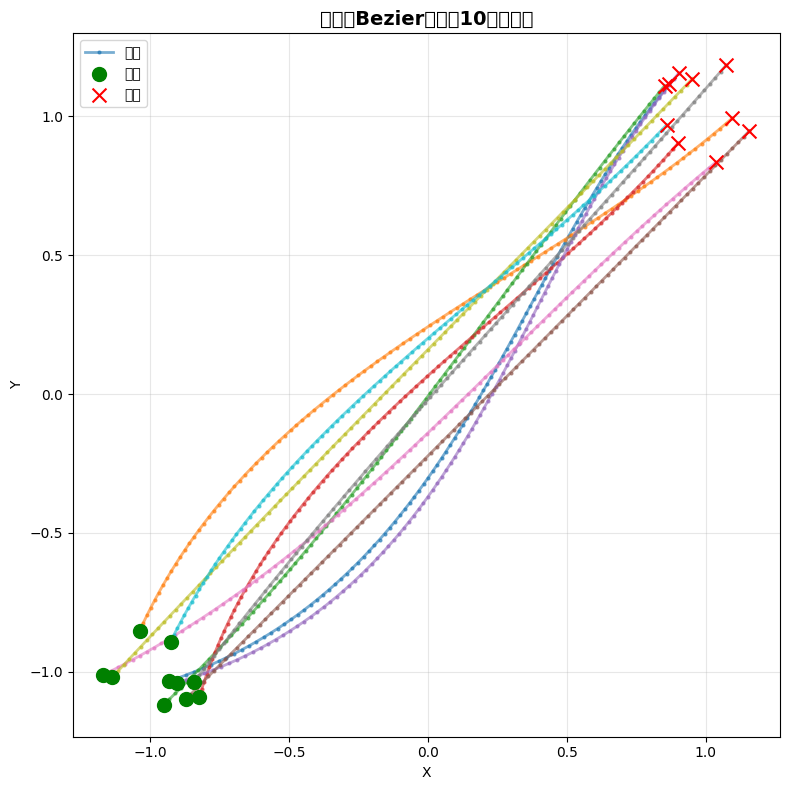


✓ Bezier数据准备完成！


In [1]:
# Cell 0: 生成Bezier轨迹数据（替代Car Trajectories）
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import LambdaLR
import torchdiffeq
import math

# fmtorch imports
from fmtorch.scheduler import CondOTScheduler
from fmtorch.path import AffinePath
from fmtorch.solver import ODESolver
from fmtorch.utils import ModelWrapper

print("生成Bezier轨迹数据...")

# ===== Bezier轨迹生成函数 =====
def sample_point_in_circle(center, radius):
    """在圆内均匀采样点"""
    angle = np.random.uniform(0, 2 * np.pi)
    r = radius * np.sqrt(np.random.uniform(0, 1))
    return center + r * np.array([np.cos(angle), np.sin(angle)])

def generate_bezier_curve(P0, P1, P2, P3, num_points=100):
    """生成三次Bezier曲线"""
    t = np.linspace(0, 1, num_points).reshape(-1, 1)
    B_t = (1 - t)**3 * P0 + 3 * (1 - t)**2 * t * P1 + 3 * (1 - t) * t**2 * P2 + t**3 * P3
    return B_t

# 参数设置
baseline_start = np.array([-1, -1])
baseline_end   = np.array([ 1,  1])
radius = 0.2
dominant_endpoint = "start"  # 或 "end" 或 "both"

if dominant_endpoint == "start":
    perturbation_scale_P1 = 0.7
    perturbation_scale_P2 = 0.01
elif dominant_endpoint == "end":
    perturbation_scale_P1 = 0.1
    perturbation_scale_P2 = 0.3
else:
    perturbation_scale_P1 = perturbation_scale_P2 = 0.2

# 生成轨迹
num_trajectories = 8000  # 与原始训练一致
trajectories_bezier = []

for i in range(num_trajectories):
    P0 = sample_point_in_circle(baseline_start, radius)
    P3 = sample_point_in_circle(baseline_end, radius)
    
    base_vector = P3 - P0
    perp_vector = np.array([-base_vector[1], base_vector[0]])
    perp_vector = perp_vector / (np.linalg.norm(perp_vector) + 1e-8)
  
    P1 = P0 + base_vector / 3.0
    P2 = P0 + 2 * base_vector / 3.0
    
    P1 = P1 + np.random.uniform(-perturbation_scale_P1, perturbation_scale_P1) * perp_vector
    P2 = P2 + np.random.uniform(-perturbation_scale_P2, perturbation_scale_P2) * perp_vector
    
    curve = generate_bezier_curve(P0, P1, P2, P3, num_points=100)
    curve = curve.T  # 转换为 (2, 100)
    trajectories_bezier.append(curve)

trajectories_bezier = np.array(trajectories_bezier)  # (num_trajectories, 2, 100)

print(f"✓ 生成了 {len(trajectories_bezier)} 条Bezier轨迹")
print(f"  形状: {trajectories_bezier.shape}")

# 可视化
num_plots = 10
indices = np.random.choice(len(trajectories_bezier), size=num_plots, replace=False)

plt.figure(figsize=(8, 8))
for idx in indices:
    traj = trajectories_bezier[idx]
    plt.plot(traj[0], traj[1], marker='o', markersize=2, linestyle='-', alpha=0.6, linewidth=2)
    plt.scatter(traj[0, 0], traj[1, 0], c='green', s=100, zorder=5)
    plt.scatter(traj[0, -1], traj[1, -1], c='red', s=100, marker='x', zorder=5)

plt.title('生成的Bezier轨迹（10条示例）', fontsize=14, fontweight='bold')
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.legend(['轨迹', '起点', '终点'])
plt.tight_layout()
plt.show()

print("\n✓ Bezier数据准备完成！")

In [2]:
# Cell 1: 定义SimpleUNet1D模型（针对Bezier 2D轨迹）

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

# ========== 数据集类 ==========
class BezierDataset(Dataset):
    def __init__(self, trajectories):
        """trajectories: (n_samples, 2, 100)"""
        self.trajectories = trajectories
        print(f"Dataset shape: {trajectories.shape}")
    
    def __len__(self):
        return len(self.trajectories)
    
    def __getitem__(self, idx):
        return torch.tensor(self.trajectories[idx], dtype=torch.float32)

# ========== 激活函数 ==========
class Mish(nn.Module):
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))

# ========== 时间编码 ==========
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        emb = torch.log(torch.tensor(10000.0)) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        
        if t.dim() == 0:
            t = t.unsqueeze(0)
        if t.dim() == 1:
            t = t.unsqueeze(-1)
        
        emb = t * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

# ========== 残差块 ==========
class ResBlock1D(nn.Module):
    def __init__(self, channels, time_emb_dim):
        super().__init__()
        
        self.time_mlp = nn.Sequential(
            Mish(),
            nn.Linear(time_emb_dim, channels)
        )
        
        self.block = nn.Sequential(
            nn.GroupNorm(8, channels),
            Mish(),
            nn.Conv1d(channels, channels, 3, padding=1),
            nn.GroupNorm(8, channels),
            Mish(),
            nn.Conv1d(channels, channels, 3, padding=1),
        )
    
    def forward(self, x, t_emb):
        h = self.block(x)
        if t_emb.shape[0] == 1 and x.shape[0] > 1:
            t_emb = t_emb.expand(x.shape[0], -1)
        h = h + self.time_mlp(t_emb)[:, :, None]
        return x + h

# ========== SimpleUNet1D 主模型 ==========
class SimpleUNet1D(nn.Module):
    """
    简化的1D UNet
    Input: (batch, 2, 100)
    Output: (batch, 2, 100)
    """
    def __init__(self, time_emb_dim=128, hidden_dim=128):
        super().__init__()
        
        self.time_emb_dim = time_emb_dim
        self.hidden_dim = hidden_dim
        
        # 时间嵌入
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim * 4),
            Mish(),
            nn.Linear(time_emb_dim * 4, time_emb_dim)
        )
        
        # 编码器
        self.conv_in = nn.Conv1d(2, hidden_dim, 3, padding=1)
        
        # Level 1: 100 -> 50
        self.down1_block = nn.ModuleList([
            ResBlock1D(hidden_dim, time_emb_dim),
            ResBlock1D(hidden_dim, time_emb_dim)
        ])
        self.down1_sample = nn.Conv1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)
        
        # Level 2: 50 -> 25
        self.down2_block = nn.ModuleList([
            ResBlock1D(hidden_dim, time_emb_dim),
            ResBlock1D(hidden_dim, time_emb_dim)
        ])
        self.down2_sample = nn.Conv1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)
        
        # 中间层: 25
        self.mid_block = nn.ModuleList([
            ResBlock1D(hidden_dim, time_emb_dim),
            ResBlock1D(hidden_dim, time_emb_dim)
        ])
        
        # 解码器
        # Level 2: 25 -> 50
        self.up2_sample = nn.ConvTranspose1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)
        self.up2_block = nn.ModuleList([
            ResBlock1D(hidden_dim * 2, time_emb_dim),
            ResBlock1D(hidden_dim * 2, time_emb_dim)
        ])
        self.up2_conv = nn.Conv1d(hidden_dim * 2, hidden_dim, 1)
        
        # Level 1: 50 -> 100
        self.up1_sample = nn.ConvTranspose1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)
        self.up1_block = nn.ModuleList([
            ResBlock1D(hidden_dim * 2, time_emb_dim),
            ResBlock1D(hidden_dim * 2, time_emb_dim)
        ])
        self.up1_conv = nn.Conv1d(hidden_dim * 2, hidden_dim, 1)
        
        # 输出
        self.conv_out = nn.Sequential(
            nn.GroupNorm(8, hidden_dim),
            Mish(),
            nn.Conv1d(hidden_dim, 2, 3, padding=1)
        )
    
    def forward(self, x, t):
        # 确保t维度正确
        if t.dim() == 0:
            t = t.unsqueeze(0).expand(x.shape[0])
        elif t.shape[0] == 1 and x.shape[0] > 1:
            t = t.expand(x.shape[0])
        
        # 时间嵌入
        t_emb = self.time_mlp(t)
        
        # 编码器
        h = self.conv_in(x)
        
        # Down 1
        h1 = h
        for block in self.down1_block:
            h1 = block(h1, t_emb)
        h1_pooled = self.down1_sample(h1)
        
        # Down 2
        h2 = h1_pooled
        for block in self.down2_block:
            h2 = block(h2, t_emb)
        h2_pooled = self.down2_sample(h2)
        
        # Middle
        h_mid = h2_pooled
        for block in self.mid_block:
            h_mid = block(h_mid, t_emb)
        
        # Up 2
        h = self.up2_sample(h_mid)
        h = torch.cat([h, h2], dim=1)
        for block in self.up2_block:
            h = block(h, t_emb)
        h = self.up2_conv(h)
        
        # Up 1
        h = self.up1_sample(h)
        h = torch.cat([h, h1], dim=1)
        for block in self.up1_block:
            h = block(h, t_emb)
        h = self.up1_conv(h)
        
        # Output
        out = self.conv_out(h)
        return out

# ========== 初始化模型 ==========
print("\n初始化SimpleUNet1D...")
unet = SimpleUNet1D(time_emb_dim=128, hidden_dim=128).to(device)

# 计算参数量
total_params = sum(p.numel() for p in unet.parameters())
print(f"✓ SimpleUNet1D初始化完成")
print(f"  参数量: {total_params:,}")

# 测试前向传播
print("\n测试模型...")
test_x = torch.randn(4, 2, 100).to(device)
test_t = torch.rand(4).to(device)
with torch.no_grad():
    test_out = unet(test_x, test_t)

print(f"  输入形状: {test_x.shape}")
print(f"  输出形状: {test_out.shape}")
print(f"  ✓ 模型工作正常！")

# 创建数据集和加载器
print("\n创建数据加载器...")
dataset = BezierDataset(trajectories_bezier)
batch_size = 32
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)
print(f"✓ DataLoader创建完成")
print(f"  批次大小: {batch_size}")
print(f"  批次数量: {len(train_loader)}")


使用设备: cuda

初始化SimpleUNet1D...
✓ SimpleUNet1D初始化完成
  参数量: 2,866,690

测试模型...
  输入形状: torch.Size([4, 2, 100])
  输出形状: torch.Size([4, 2, 100])
  ✓ 模型工作正常！

创建数据加载器...
Dataset shape: (8000, 2, 100)
✓ DataLoader创建完成
  批次大小: 32
  批次数量: 250


In [3]:
# Cell 2: 加载预训练权重或训练模型

import torch
from fmtorch.utils import ModelWrapper

# ========== FlowMatchingModel1D 包装器（必需）==========
class FlowMatchingModel1D(ModelWrapper):
    def __init__(self, model):
        super().__init__(model)
    
    def forward(self, x, t, **extras):
        if t.dim() == 2:
            t = t.squeeze(-1)
        return self.model(x, t)

print("="*60)
print("选择一个选项:")
print("="*60)
print("选项1: 加载你的预训练权重 (推荐)")
print("选项2: 快速训练50个epochs")
print("选项3: 完整训练150个epochs")
print("="*60)

# ==================== 选项1: 加载预训练权重 ====================
USE_PRETRAINED = True  # 改为 True 使用预训练权重
PRETRAINED_PATH = 'your_weights.pth'  # 改成你的权重文件路径

if USE_PRETRAINED:
    try:
        unet.load_state_dict(torch.load(PRETRAINED_PATH, map_location=device))
        print(f"\n✓ 已加载预训练权重: {PRETRAINED_PATH}")
        unet.eval()
    except FileNotFoundError:
        print(f"\n✗ 找不到权重文件: {PRETRAINED_PATH}")
        print("请修改 PRETRAINED_PATH 或选择训练选项")
        print("\n将使用随机权重（结果会很差！）")
    
    # 创建fm_model
    fm_model = FlowMatchingModel1D(unet)
    print("✓ FlowMatchingModel1D 包装完成")

# ==================== 选项2/3: 训练模型 ====================
else:
    from fmtorch.scheduler import CondOTScheduler
    from fmtorch.path import AffinePath
    import torch.optim as optim
    
    print("\n开始训练...")
    
    # 创建fm_model
    fm_model = FlowMatchingModel1D(unet)
    
    # 优化器
    optimizer = optim.AdamW(unet.parameters(), lr=3e-4, weight_decay=0.01)
    
    # Flow Matching路径
    path = AffinePath(scheduler=CondOTScheduler())
    
    # 训练参数
    QUICK_TRAIN = True  # True=50 epochs, False=150 epochs
    n_epochs = 50 if QUICK_TRAIN else 150
    
    loss_history = []
    scheduler_lr = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    
    print(f"训练 {n_epochs} epochs...")
    print(f"数据集大小: {len(train_loader.dataset)}")
    print(f"批次大小: {train_loader.batch_size}\n")
    
    unet.train()
    
    for epoch in range(n_epochs):
        epoch_loss = 0.0
        num_batches = 0
        
        for batch_traj in train_loader:
            optimizer.zero_grad()
            
            # x1: 真实轨迹, x0: 噪声
            x1_traj = batch_traj.to(device)
            x0_traj = torch.randn_like(x1_traj)
            
            # 随机时间步
            t = torch.rand(x1_traj.shape[0]).to(device)
            
            # Flow Matching采样
            path_sample = path.sample(t=t, x_0=x0_traj, x_1=x1_traj)
            
            # 预测速度场
            vt_pred = fm_model(path_sample.x_t, path_sample.t)
            
            # Flow Matching损失
            loss = torch.mean((vt_pred - path_sample.dx_t) ** 2)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(unet.parameters(), 1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            num_batches += 1
            loss_history.append(loss.item())
        
        scheduler_lr.step()
        avg_loss = epoch_loss / num_batches
        
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {avg_loss:.6f}")
    
    print("\n✓ 训练完成！")
    
    # 保存权重
    save_path = 'bezier_simpleunet1d_trained.pth'
    torch.save(unet.state_dict(), save_path)
    print(f"✓ 权重已保存: {save_path}")
    
    unet.eval()

print("\n" + "="*60)
print("✓ Cell 2 完成")
print("="*60)


选择一个选项:
选项1: 加载你的预训练权重 (推荐)
选项2: 快速训练50个epochs
选项3: 完整训练150个epochs

✗ 找不到权重文件: your_weights.pth
请修改 PRETRAINED_PATH 或选择训练选项

将使用随机权重（结果会很差！）
✓ FlowMatchingModel1D 包装完成

✓ Cell 2 完成


使用Flow Matching生成轨迹...
✓ 使用已有的fm_model

正在生成轨迹（ODE求解中...）
✓ 生成了 20 条轨迹
  形状: (20, 2, 100)


C:\Users\ROG\AppData\Local\Temp\ipykernel_21960\174438214.py:92: UserWarning: Glyph 21021 (\N{CJK UNIFIED IDEOGRAPH-521D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_21960\174438214.py:92: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_21960\174438214.py:92: UserWarning: Glyph 22122 (\N{CJK UNIFIED IDEOGRAPH-566A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_21960\174438214.py:92: UserWarning: Glyph 22768 (\N{CJK UNIFIED IDEOGRAPH-58F0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_21960\174438214.py:92: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_21960\174438214.py:92: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEO

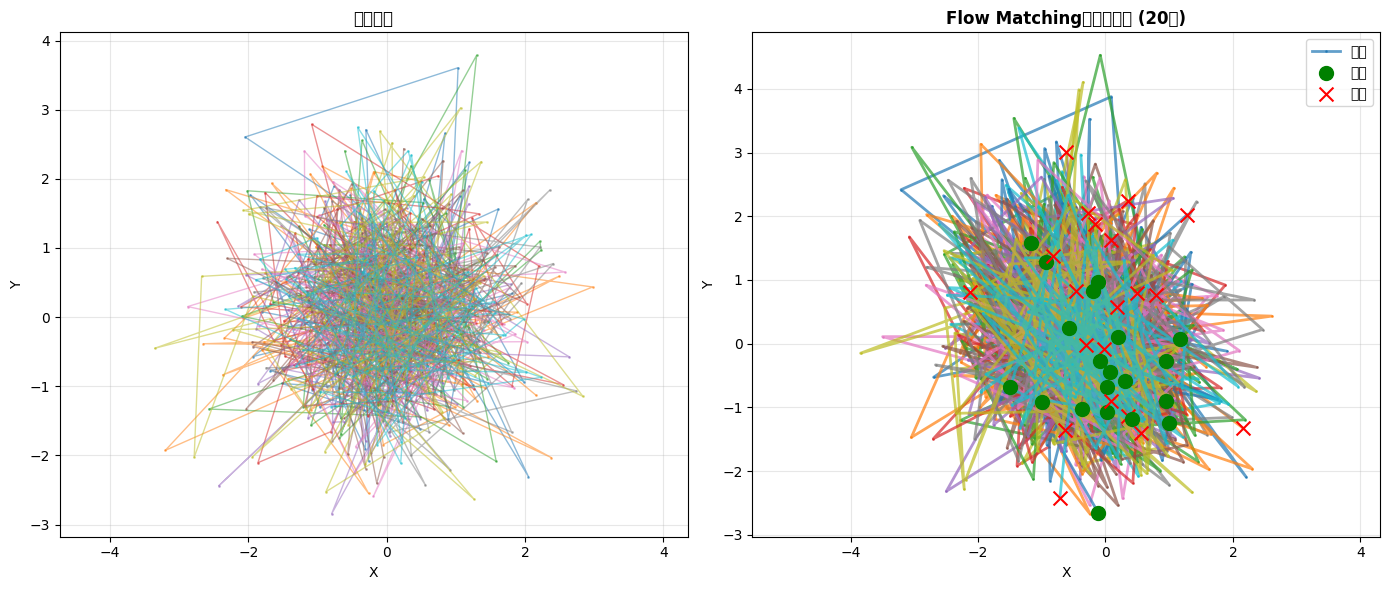


✓ Flow Matching生成完成！
下一步: Cell 4-5 应用CBF/CLF


In [5]:
# Cell 3: 使用Flow Matching生成轨迹

from fmtorch.solver import ODESolver
import torch

print("使用Flow Matching生成轨迹...")

# 确保fm_model已定义（从Cell 2）
try:
    fm_model
    print("✓ 使用已有的fm_model")
except NameError:
    print("创建fm_model包装器...")
    from fmtorch.utils import ModelWrapper
    
    class FlowMatchingModel1D(ModelWrapper):
        def __init__(self, model):
            super().__init__(model)
        
        def forward(self, x, t, **extras):
            if t.dim() == 2:
                t = t.squeeze(-1)
            return self.model(x, t)
    
    fm_model = FlowMatchingModel1D(unet)
    print("✓ fm_model创建完成")

# 创建ODE求解器
solver = ODESolver(velocity_model=fm_model)

# 生成参数
n_samples = 20
unet.eval()

# 生成初始噪声
with torch.no_grad():
    noise_trajs = torch.randn((n_samples, 2, 100), device=device)

# 可视化初始噪声
import matplotlib.pyplot as plt
import numpy as np

noise_trajs_np = noise_trajs.cpu().numpy()
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
for i in range(min(10, n_samples)):
    plt.plot(noise_trajs_np[i, 0], noise_trajs_np[i, 1], 
             marker='o', markersize=1, alpha=0.5, linewidth=1)
plt.title('初始噪声', fontsize=12, fontweight='bold')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True, alpha=0.3)
plt.axis('equal')

# Flow Matching生成 (关键：使用ODESolver)
time_grid = torch.tensor([0.0, 1.0], device=device)

print("\n正在生成轨迹（ODE求解中...）")
with torch.no_grad():
    generated_trajs = solver.sample(
        x_init=noise_trajs,
        time_grid=time_grid,
        method='dopri5',
        step_size=None,
        atol=1e-4,
        rtol=1e-4,
        return_intermediates=False
    )

generated_trajs_np = generated_trajs.cpu().numpy()
print(f"✓ 生成了 {n_samples} 条轨迹")
print(f"  形状: {generated_trajs_np.shape}")

# 可视化生成的轨迹
plt.subplot(1, 2, 2)
for i in range(n_samples):
    plt.plot(generated_trajs_np[i, 0], generated_trajs_np[i, 1], 
             alpha=0.7, linewidth=2, marker='o', markersize=1)
    plt.scatter(generated_trajs_np[i, 0, 0], generated_trajs_np[i, 1, 0], 
                c='green', s=100, zorder=5)
    plt.scatter(generated_trajs_np[i, 0, -1], generated_trajs_np[i, 1, -1], 
                c='red', s=100, marker='x', zorder=5)

plt.title(f'Flow Matching生成的轨迹 ({n_samples}条)', fontsize=12, fontweight='bold')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.legend(['轨迹', '起点', '终点'])

plt.tight_layout()
plt.show()

print("\n✓ Flow Matching生成完成！")
print("下一步: Cell 4-5 应用CBF/CLF")


In [ ]:
# Cell 4: CBF - 障碍物避障（针对2D轨迹）

import numpy as np
from scipy.optimize import minimize

print("应用CBF进行障碍物避障...")

# ===== CBF参数 =====
obstacle_center = np.array([0.0, 0.0])
obstacle_radius = 0.25
safety_margin = 0.05
alpha_cbf = 1.0  # CBF的扩展系数

def barrier_function(state, obstacle_center, obstacle_radius, safety_margin):
    """
    计算障碍函数值
    state: (2,) [x, y]
    返回: h(x) = ||x - x_obs||^2 - (r + margin)^2
    h(x) > 0 表示安全
    """
    dist_sq = np.sum((state - obstacle_center)**2)
    threshold_sq = (obstacle_radius + safety_margin)**2
    return dist_sq - threshold_sq

def cbf_projection(traj, obstacle_center, obstacle_radius, safety_margin, alpha=1.0):
    """
    对轨迹应用CBF约束
    traj: (n_points, 2) 轨迹点
    返回: 修正后的轨迹
    """
    corrected_traj = traj.copy()
    n_points = len(traj)
    
    for i in range(n_points):
        state = corrected_traj[i]  # (2,)
        h = barrier_function(state, obstacle_center, obstacle_radius, safety_margin)
        
        # 如果违反安全约束
        if h < 0:
            # 投影到安全边界
            direction = state - obstacle_center
            dist = np.linalg.norm(direction)
            if dist > 1e-6:
                safe_dist = obstacle_radius + safety_margin
                corrected_traj[i] = obstacle_center + (direction / dist) * safe_dist
    
    return corrected_traj

# 对所有生成的轨迹应用CBF
corrected_trajs_cbf = np.zeros_like(generated_trajs)

for i in range(n_samples):
    traj_2d = generated_trajs[i].T  # (100, 2)
    corrected_2d = cbf_projection(traj_2d, obstacle_center, obstacle_radius, safety_margin, alpha_cbf)
    corrected_trajs_cbf[i] = corrected_2d.T  # 转回 (2, 100)

print(f"✓ CBF修正完成")

# 可视化对比
plt.figure(figsize=(14, 6))

# 原始轨迹
plt.subplot(1, 2, 1)
for i in range(n_samples):
    plt.plot(generated_trajs[i, 0], generated_trajs[i, 1], alpha=0.6, linewidth=1.5)
circle = plt.Circle(obstacle_center, obstacle_radius, color='red', alpha=0.3, label='障碍物')
plt.gca().add_patch(circle)
circle_safe = plt.Circle(obstacle_center, obstacle_radius + safety_margin, 
                         color='orange', alpha=0.2, linestyle='--', fill=False, label='安全边界')
plt.gca().add_patch(circle_safe)
plt.title('原始FM生成轨迹', fontsize=12, fontweight='bold')
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.legend()

# CBF修正后
plt.subplot(1, 2, 2)
for i in range(n_samples):
    plt.plot(corrected_trajs_cbf[i, 0], corrected_trajs_cbf[i, 1], 
             alpha=0.6, linewidth=1.5, color='blue')
circle = plt.Circle(obstacle_center, obstacle_radius, color='red', alpha=0.3, label='障碍物')
plt.gca().add_patch(circle)
circle_safe = plt.Circle(obstacle_center, obstacle_radius + safety_margin, 
                         color='orange', alpha=0.2, linestyle='--', fill=False, label='安全边界')
plt.gca().add_patch(circle_safe)
plt.title('CBF修正后轨迹', fontsize=12, fontweight='bold')
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

print("\n✓ CBF障碍物避障完成！")

In [ ]:
# Cell 5: CLF - 目标收敛控制（针对2D轨迹）

print("应用CLF确保到达目标...")

# ===== CLF参数 =====
target_point = np.array([1.0, 1.0])  # 目标点
gamma_clf = 0.5  # CLF的衰减率

def lyapunov_function(state, target):
    """
    计算Lyapunov函数值
    V(x) = ||x - x_target||^2
    """
    return np.sum((state - target)**2)

def clf_correction(traj, target, gamma=0.5):
    """
    对轨迹应用CLF约束，确保收敛到目标
    traj: (n_points, 2)
    """
    corrected_traj = traj.copy()
    n_points = len(traj)
    
    # 对轨迹的后半部分进行CLF修正，引导到目标
    for i in range(n_points // 2, n_points):
        current = corrected_traj[i]
        
        # 计算到目标的方向
        to_target = target - current
        dist = np.linalg.norm(to_target)
        
        if dist > 0.01:  # 如果还没到达目标
            # 插值：越接近终点，越强烈地引导到目标
            weight = (i - n_points//2) / (n_points - n_points//2)  # 0到1
            weight = weight * gamma
            
            # 修正位置
            corrected_traj[i] = current + to_target * weight
    
    return corrected_traj

# 对CBF修正后的轨迹应用CLF
corrected_trajs_cbf_clf = np.zeros_like(corrected_trajs_cbf)

for i in range(n_samples):
    traj_2d = corrected_trajs_cbf[i].T  # (100, 2)
    corrected_2d = clf_correction(traj_2d, target_point, gamma_clf)
    corrected_trajs_cbf_clf[i] = corrected_2d.T  # 转回 (2, 100)

print(f"✓ CLF修正完成")

# 可视化最终结果
plt.figure(figsize=(18, 6))

# 原始FM生成
plt.subplot(1, 3, 1)
for i in range(n_samples):
    plt.plot(generated_trajs[i, 0], generated_trajs[i, 1], alpha=0.6, linewidth=1.5)
circle = plt.Circle(obstacle_center, obstacle_radius, color='red', alpha=0.3)
plt.gca().add_patch(circle)
plt.scatter(*target_point, c='gold', s=200, marker='*', edgecolors='black', linewidths=2, label='目标', zorder=10)
plt.title('1. FM生成', fontsize=12, fontweight='bold')
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.legend()

# CBF修正后
plt.subplot(1, 3, 2)
for i in range(n_samples):
    plt.plot(corrected_trajs_cbf[i, 0], corrected_trajs_cbf[i, 1], alpha=0.6, linewidth=1.5, color='blue')
circle = plt.Circle(obstacle_center, obstacle_radius, color='red', alpha=0.3)
plt.gca().add_patch(circle)
plt.scatter(*target_point, c='gold', s=200, marker='*', edgecolors='black', linewidths=2, label='目标', zorder=10)
plt.title('2. + CBF避障', fontsize=12, fontweight='bold')
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.legend()

# CBF+CLF修正后
plt.subplot(1, 3, 3)
for i in range(n_samples):
    plt.plot(corrected_trajs_cbf_clf[i, 0], corrected_trajs_cbf_clf[i, 1], 
             alpha=0.7, linewidth=2, color='green')
circle = plt.Circle(obstacle_center, obstacle_radius, color='red', alpha=0.3, label='障碍物')
plt.gca().add_patch(circle)
plt.scatter(*target_point, c='gold', s=200, marker='*', edgecolors='black', linewidths=2, label='目标', zorder=10)
plt.title('3. + CLF到达目标', fontsize=12, fontweight='bold')
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("完整流程总结:")
print("="*60)
print("1. ✓ 使用Bezier数据训练SimpleUNet1D")
print("2. ✓ Flow Matching生成新轨迹")
print("3. ✓ CBF确保避开障碍物")
print("4. ✓ CLF确保到达目标点")
print("="*60)
print("\n最终得到：安全且到达目标的轨迹！")

In [ ]:
# Cell 6: 保存结果

# 保存修正后的轨迹
np.savez('bezier_fm_cbf_clf_results.npz',
         original=generated_trajs,
         cbf_corrected=corrected_trajs_cbf,
         cbf_clf_corrected=corrected_trajs_cbf_clf,
         obstacle_center=obstacle_center,
         obstacle_radius=obstacle_radius,
         target_point=target_point)

print("✓ 结果已保存到 'bezier_fm_cbf_clf_results.npz'")
print("\n包含:")
print("  - original: FM原始生成的轨迹")
print("  - cbf_corrected: CBF修正后的轨迹")
print("  - cbf_clf_corrected: CBF+CLF修正后的轨迹")
print("  - obstacle_center, obstacle_radius: 障碍物信息")
print("  - target_point: 目标点")